In [1]:
# Uncomment and run this cell if you're on Colab or Kaggle
# !git clone https://github.com/nlp-with-transformers/notebooks.git
# %cd notebooks
# from install import *
# install_requirements(is_chapter6=True)

In [10]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
print(os.environ["HF_HUB_DISABLE_XET"])

1


In [11]:
#hide
from utils import *
setup_chapter()

Using transformers v4.57.1
Using datasets v5.0.0


In [12]:
# hide
from transformers import pipeline, set_seed

# Summarization

## The CNN/DailyMail Dataset

In [13]:
#hide_output
from datasets import load_dataset

dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")
print(f"Features: {dataset['train'].column_names}")

# La versión 3.0.0 tiene 287.113 ejemplos de entrenamiento, 13.368 de validación y 11.490 de test. 
# Los campos son article, highlights e id

Features: ['article', 'highlights', 'id']


In [14]:
# veamos un extracto
sample = dataset["train"][1]

# sample es un diccionario similar a
#{
#    "article": "...",
#    "highlights": "...",
#    "id": "..."
#}

print(f"""
Article (excerpt of 500 characters, total length: {len(sample["article"])}):
""")
print(sample["article"][:500])
print(f'\nSummary (length: {len(sample["highlights"])}):')
print(sample["highlights"])


Article (excerpt of 500 characters, total length: 4051):

Editor's note: In our Behind the Scenes series, CNN correspondents share their
experiences in covering news and analyze the stories behind the events. Here,
Soledad O'Brien takes users inside a jail where many of the inmates are mentally
ill. An inmate housed on the "forgotten floor," where many mentally ill inmates
are housed in Miami before trial. MIAMI, Florida (CNN) -- The ninth floor of the
Miami-Dade pretrial detention facility is dubbed the "forgotten floor." Here,
inmates with the most s

Summary (length: 281):
Mentally ill inmates in Miami are housed on the "forgotten floor"
Judge Steven Leifman says most are there as a result of "avoidable felonies"
While CNN tours facility, patient shouts: "I am the son of the president"
Leifman says the system is unjust and he's fighting for change .


## Text Summarization Pipelines

In [15]:
# Aquí está preparando un texto común para comparar varios modelos de summarization.

sample_text = dataset["train"][1]["article"][:2000]
# Coge el segundo ejemplo de train, accede al artículo de ese ejemplo y quédate con sus primeros 2.000 caracteres.

# We'll collect the generated summaries of each model in a dictionary
summaries = {}

In [16]:
#hide_output
import nltk
# nltk -> (Natural Language Toolkit), una librería clásica de NLP
# nltk -> No es un modelo Transformer. Es una caja de herramientas de procesamiento de lenguaje:
    # tokenizacion
    # stemming
    # lematización
    # corpus
    # WordNet
    # utilidades NLP
from nltk.tokenize import sent_tokenize # divide texto en frases ( no en subpalabras!)

nltk.download("punkt_tab") # Contiene los parámetros lingüísticos que PunktTokenizer necesita para detectar límites de oracionesusa información lingüística para intentar reconocer qué puntos terminan una frase y cuáles no.
nltk.download("wordnet") # es una base léxica de palabras inglesas y relaciones semánticas entre ellas.
nltk.download("omw-1.4") # Open Multilingual WordNet, que amplía recursos de WordNet a múltiples idiomas

# wordnet y omw-1.4 lo usaremos para métricas / evaluación

[nltk_data] Downloading package punkt_tab to /home/srmjf/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/srmjf/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/srmjf/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
string = "The U.S. are a country. The U.N. is an organization."
sent_tokenize(string)

['The U.S. are a country.', 'The U.N. is an organization.']

### Summarization Baseline


In [18]:
def three_sentence_summary(text):
    return "\n".join(sent_tokenize(text)[:3])

# sent_tokenize(text) -> Divide text en una lista de frases
# [:3] -> Selecciona las tres primeras oraciones
# "\n".join( -> Une las tres frases con un salto de línea (\n) como separador



In [19]:
summaries["baseline"] = three_sentence_summary(sample_text)
# crea la clave baseline dentro del diccionario summaries (definido al principio)

### GPT-2

In [20]:
#hide_output
from transformers import pipeline, set_seed

set_seed(42)
pipe = pipeline("text-generation", model="gpt2-xl") # Crea un pipeline de generación de texto usando GPT-2 XL.
gpt2_query = sample_text + "\nTL;DR:\n"
# TL;DR significa “Too Long; Didn't Read” y es una convención muy usada en internet, 
# especialmente asociada a sitios como Reddit, para introducir un resumen de un texto largo.
# GPT2 en su entrenamiento ha visto:
    # texto largo, 
    # texto largo, 
    # texto largo 
    # TL;DR: resumen corto

pipe_out = pipe(gpt2_query, max_length=512, clean_up_tokenization_spaces=True)
# max_length=512 -> la secuencia total —prompt más generación— puede tener como máximo 512 tokens.

summaries["gpt2"] = "\n".join(
    sent_tokenize(pipe_out[0]["generated_text"][len(gpt2_query) :]))
# [len(gpt2_query):] -> elimina del principio tantos caracteres como tiene gpt2_query, es decir, quita:
# sample_text + "\nTL;DR:\n"

### T5

<img alt="T5" width="700" caption="Diagram of T5's text-to-text framework (courtesy of Colin Raffel); besides translation and summarization, the CoLA (linguistic acceptability) and STSB (semantic similarity) tasks are shown" src="images/chapter08_t5.png" id="T5"/>

In [11]:
#hide_output
# T5 = modelo encoder + decoder

pipe = pipeline("summarization", model="t5-large") # si el modelo no está descargado lo carga en mi caché
pipe_out = pipe(sample_text)
summaries["t5"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

el resultado de pipe tendrá un resultado como:


[
    {
        "summary_text": "texto del resumen..."
    }
]


### BART

In [13]:
#hide_output
# BART -> encoder + decoder
pipe = pipeline("summarization", model="facebook/bart-large-cnn")
pipe_out = pipe(sample_text)
summaries["bart"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

### PEGASUS

<img alt="pegasus" width="700" caption="Diagram of PEGASUS architecture (courtesy of Jingqing Zhang et al.)" src="images/chapter08_pegasus.png" id="pegasus"/>

In [21]:
#hide_output
pipe = pipeline("summarization", model="google/pegasus-cnn_dailymail")
# este checkpoint de pegasus está ajustado específicamente para summarization sobre CNN/DailyMail
pipe_out = pipe(sample_text)
summaries["pegasus"] = pipe_out[0]["summary_text"].replace(" .<n>", ".\n")
# Aquí no hace falta usar sent_tokenize porque el modelo tiene un token que separa las frases (" .<n>"
# Sólo hya que cambiarlo por   ".\n"

## Comparing Different Summaries

In [15]:
print("GROUND TRUTH")
print(dataset["train"][1]["highlights"]) # imprime el resumen de referencia del propio dataset
print("")

for model_name in summaries:
    print(model_name.upper()) # imprime el nombre en mayúsculas
    print(summaries[model_name])
    print("")

GROUND TRUTH
Mentally ill inmates in Miami are housed on the "forgotten floor"
Judge Steven Leifman says most are there as a result of "avoidable felonies"
While CNN tours facility, patient shouts: "I am the son of the president"
Leifman says the system is unjust and he's fighting for change .

BASELINE
Editor's note: In our Behind the Scenes series, CNN correspondents share their
experiences in covering news and analyze the stories behind the events.
Here, Soledad O'Brien takes users inside a jail where many of the inmates are
mentally ill. An inmate housed on the "forgotten floor," where many mentally ill
inmates are housed in Miami before trial.
MIAMI, Florida (CNN) -- The ninth floor of the Miami-Dade pretrial detention
facility is dubbed the "forgotten floor."

GPT2
The mentally ill aren't being treated properly and are being housed in an
environment that is not comfortable or conducive to their treatment.
A lot of the mentally ill are in jail because they are not in treatment.
Th

## Measuring the Quality of Generated Text

### BLEU

# hide_output
from datasets import load_metric

bleu_metric = load_metric("sacrebleu")

Esto ya no se usa:

En el entorno antiguo, las métricas estaban integradas en datasets. Esa API fue deprecada y load_metric acabó eliminado de datasets; Hugging Face trasladó este flujo a la librería evaluate.

In [16]:
import evaluate

bleu_metric = evaluate.load("sacrebleu")

In [17]:
import pandas as pd # para redondear
import numpy as np # mara mostrar resultado como tabla

bleu_metric.add(
    prediction="the the the the the the", reference=["the cat is on the mat"])
results = bleu_metric.compute(smooth_method="floor", smooth_value=0) # calcula la métrica con los ejemplos añadidos
# smooth_method="floor"-> El smoothing sirve para evitar que una precisión de n-gramas igual a cero anule todo el BLEU.
results["precisions"] = [np.round(p, 2) for p in results["precisions"]]
pd.DataFrame.from_dict(results, orient="index", columns=["Value"])

,Value
score,0.0
counts,"[2, 0, 0, 0]"
totals,"[6, 5, 4, 3]"
precisions,"[33.33, 0.0, 0.0, 0.0]"
bp,1.0
sys_len,6
ref_len,6


`results` contiene:

```python
{
    "score": 0.0,
    "counts": [2, 0, 0, 0],
    "totals": [6, 5, 4, 3],
    "precisions": [33.33, 0.0, 0.0, 0.0],
    "bp": 1.0,
    "sys_len": 6,
    "ref_len": 6
}
```

La interpretación es la siguiente:

```text
counts     → coincidencias válidas para 1-, 2-, 3- y 4-gramas
totals     → n-gramas totales generados
precisions → precisión de cada orden
bp         → brevity penalty
sys_len    → longitud de la predicción
ref_len    → longitud de la referencia
score      → BLEU final
```

In [18]:
bleu_metric.add(
    prediction="the cat is on mat", reference=["the cat is on the mat"])
results = bleu_metric.compute(smooth_method="floor", smooth_value=0)
results["precisions"] = [np.round(p, 2) for p in results["precisions"]]
pd.DataFrame.from_dict(results, orient="index", columns=["Value"])

,Value
score,57.893007
counts,"[5, 3, 2, 1]"
totals,"[5, 4, 3, 2]"
precisions,"[100.0, 75.0, 66.67, 50.0]"
bp,0.818731
sys_len,5
ref_len,6


### ROUGE

In [19]:
# hide_output
rouge_metric = evaluate.load("rouge")

In [20]:
reference = dataset["train"][1]["highlights"] # el ground truth -> Todos los modelos se compararña con esta referencia
records = [] # lista vacía donde iremos guardando los resultados de cada modelo
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"] # métricas que queremos guardar

for model_name in summaries:
    rouge_metric.add(prediction=summaries[model_name], reference=reference)
    score = rouge_metric.compute()
    rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
    # otra forma de hacerlo:
    # rouge_dict = {rn: score[rn] for rn in rouge_names}
    
    records.append(rouge_dict)
pd.DataFrame.from_records(records, index=summaries.keys()) # convertimos a dataframe 
# from records<89 -> lee cada diccionario como una fila del DataFrame

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.365079,0.145161,0.206349,0.285714
gpt2,0.136364,0.018349,0.100000,0.118182
t5,0.382979,0.130435,0.255319,0.382979
bart,0.475248,0.222222,0.316832,0.415842
pegasus,0.500000,0.325581,0.431818,0.477273


## 1. `for model_name in summaries:`

Aquí recorre las claves del diccionario:

```python
summaries = {
    "baseline": "...",
    "gpt2": "...",
    "t5": "...",
    "bart": "...",
    "pegasus": "..."
}
```

## 2. Añadir la comparación

```python
rouge_metric.add(
    prediction=summaries[model_name],
    reference=reference
)
```

Añadimos una comparación entre la referencia y la predicción.

## 3. Calcular ROUGE

```python
score = rouge_metric.compute()
```

Calculamos ROUGE.

Genera algo como:

```python
{
    "rouge1": ...,
    "rouge2": ...,
    "rougeL": ...,
    "rougeLsum": ...
}
```

## 4. Crear un nuevo diccionario

```python
rouge_dict = dict(
    (rn, score[rn])
    for rn in rouge_names
)
```

Creamos un diccionario nuevo.

Cada vez:

```python
score[rn]
```

obtiene:

```python
score["rouge1"]
score["rouge2"]
score["rougeL"]
score["rougeLsum"]
```

Y genera pares como:

```python
("rouge1", 0.42)
("rouge2", 0.18)
("rougeL", 0.35)
("rougeLsum", 0.36)
```

Después:

```python
dict(...)
```

los convierte en:

```python
{
    "rouge1": 0.42,
    "rouge2": 0.18,
    "rougeL": 0.35,
    "rougeLsum": 0.36
}
```

| Métrica | ¿Qué compara? | ¿Qué evalúa? |
|---|---|---|
| **ROUGE-1** | Unigramas (palabras individuales) | ¿Se usan las mismas palabras importantes? |
| **ROUGE-2** | Bigramas (pares de palabras consecutivas) | ¿Se mantienen pequeñas secuencias de palabras? |
| **ROUGE-L** | Longest Common Subsequence (LCS) | ¿Se conserva el orden general del texto? |
| **ROUGE-Lsum** | LCS para resúmenes de varias frases | Igual que ROUGE-L, pero adaptado a documentos completos. |

## Evaluating PEGASUS on the CNN/DailyMail Dataset

In [21]:
# hide
# ignore this cell it is only to be able to start running the notebook here
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import evaluate

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")
# rouge_metric = load_metric("rouge", cache_dir=None) API antigua

rouge_metric = evaluate.load("rouge", cache_dir= None) # API actual
# o estás especificando manualmente una carpeta de caché para la métrica. evaluate utilizará su comportamiento/ruta de caché por defecto.
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]



In [22]:
# Esta función evalúa el baseline de las tres primeras frases sobre un dataset completo, no sobre un único artículo como hicimos antes.

def evaluate_summaries_baseline(dataset, metric,
                                column_text="article", 
                                column_summary="highlights"):

    # Recibe cuatro parámetros: 
        # dataset es el conjunto de ejemplos que quieres evaluar 
        # metric es el objeto ROUGE. L
        # Los otros dos son nombres de columnas y tienen valores por defecto:
    summaries = [three_sentence_summary(text) for text in dataset[column_text]]
    metric.add_batch(predictions=summaries,
                     references=dataset[column_summary]) # ..add_batch -> añade muchas comparaciones a la vez (summaries[0] vs highlight[0]...   
    score = metric.compute() # calcula ROUGE. Un ROUGE agregado
    return score # devuelve un diccionario con las puntuaciones score

In [23]:
test_sampled = dataset["test"].shuffle(seed=42).select(range(100))

score = evaluate_summaries_baseline(test_sampled, rouge_metric)
rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
# rouge_dict = dict((rn, score[rn]) for rn in rouge_names) de otra manera

pd.DataFrame.from_dict(rouge_dict, orient="index", columns=["baseline"]).T 
#.T transpone -> intercambia filas por columnas 

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.386229,0.16465,0.245916,0.352733


Vamos a implementar una evaluación de PEGASUS sobre muchos artículos y por lotes:

```text
dataset
  ↓
dividir artículos y referencias en batches
  ↓
tokenizar cada batch
  ↓
PEGASUS genera resúmenes
  ↓
decodificar
  ↓
comparar con highlights mediante ROUGE
  ↓
devolver score agregado

In [24]:

from tqdm import tqdm # mostrará barra de progreso
import torch

device = "cuda" if torch.cuda.is_available() else "cpu" 

def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        # estructura de range-> range(inicio, fin, step)
        yield list_of_elements[i : i + batch_size] # yield porque es un generador de batches para la función que va después

def evaluate_summaries_pegasus(dataset, metric, model, tokenizer, 
                               batch_size=16, device=device, 
                               column_text="article", 
                               column_summary="highlights"):
    # esta función recibe:
        # dataset: los ejemplos que quierp evaluar
        # metric: ROUGE
        # modelo: PEGASUS
        # tokenizer: Tokenizado de Pegasus
        # batch size = 16-> procesa 16 artículos de cada vez
        # device: GPU o CPU
        # column_text: columna de entrada (referencia)
        # columns_summary: columna con los resúmenes
    article_batches = list(chunks(dataset[column_text], batch_size)) # divide artículos(referencias) en batches -> aplica función chunk
    target_batches = list(chunks(dataset[column_summary], batch_size)) # divide resúmenes(objetivos) en batches -> aplica función chunk

    for article_batch, target_batch in tqdm(
        zip(article_batches, target_batches), total=len(article_batches)): # recorre ambas listas conjumntamente, lo mete entqd para barra de seguimiento
        
        inputs = tokenizer(article_batch, max_length=1024,  truncation=True, 
                        padding=True, return_tensors="pt")
        # convierte el texto en tensores:
        # article_batch -> tokenizer -> input_ids, attention_mask
        # con un batch completo:
            # input_ids.shape       ≈ [16, 1024]
            # attention_mask.shape  ≈ [16, 1024]
        
        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                         attention_mask=inputs["attention_mask"].to(device), 
                         length_penalty=0.8, num_beams=4, max_length=64)
        # PEGASUS genera los resúmenes. 1) Mueve los yensores a GPU 2) Genera un resumen por artículo
        # length_penalty -> ajusta cómo se valoran las secuencias
        # num_beam=8 -> usa beam_searcg con 8 candidatos
        # max_length=128 -> cada resumen máximo de 128 tokens
        # summaries todavía no contiene texto. Contiene IDs de tokens.
        
        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True, 
                                clean_up_tokenization_spaces=True) 
               for s in summaries]
        
        # decodificamos los IDs
        # skip_special_tokens=True: elimina <pad>, </s>, etc.
        # clean_up_tokenization_spaces=True: limpia algunos espacios artificiales.
        
        decoded_summaries = [d.replace("<n>", " ") for d in decoded_summaries]
        # limpia los <n> que separan cada palabra
        metric.add_batch(predictions=decoded_summaries, references=target_batch) # añade el ROUGE al batch
        # la métrica va acumulando todos los batches
        
    score = metric.compute() # calcula el ROUGE agregado
    return score

In [32]:
# hide_output

# Ahora vamos a evaluar PEGASUS sobre los 1000 artículos del conjunto de test y medir su ROUGE.

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)
score = evaluate_summaries_pegasus(test_sampled, rouge_metric, 
                                   model, tokenizer, batch_size=2)
rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

100%|██████████████████████████████████████████████████████████████████████████████| 50/50 [21:12<00:00, 25.45s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.429664,0.199207,0.302865,0.368739


In [33]:
# hide_input 
pd.DataFrame(rouge_dict, index=["pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.429664,0.199207,0.302865,0.368739


## Training a Summarization Model

In [7]:
# hide_output
from datasets import load_dataset

dataset_samsum = load_dataset("knkarthick/samsum") # Carga el dataset SAMSum desde Hugging Face Datasets.-> Contiene varios splits
split_lengths = [len(dataset_samsum[split])for split in dataset_samsum] # creamos una lista con el tamaño de cada split
# esta lista sólo devuelve números pero no el nombre de cada split. Funciona porque conocemos el orden de iteración 
# de un DatasetDict: 1) train, 2) validation y 3) test
print(f"Split lengths: {split_lengths}") # imprime split_length
print(f"Features: {dataset_samsum['train'].column_names}") # imprime el nombre de las columnas del dataset:
    # id -> identificador del ejemplo
    # dialogue -> conversación original -> Nuestro input 
    # summary -> resumen -> Nuestro target
print("\nDialogue:")
print(dataset_samsum["test"][0]["dialogue"])
print("\nSummary:")
print(dataset_samsum["test"][0]["summary"])

Split lengths: [14731, 818, 819]
Features: ['id', 'dialogue', 'summary']

Dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.


### Evaluating PEGASUS on SAMSum

In [29]:
# Recordemos que antes: pipe = pipeline("summarization", model="google/pegasus-cnn_dailymail")

pipe_out = pipe(dataset_samsum["test"][0]["dialogue"])
print("Summary:")
print(pipe_out[0]["summary_text"].replace(" .<n>", ".\n"))

Summary:
Amanda: Ask Larry Amanda: He called her last time we were at the park together.
Hannah: I'd rather you texted him.
Amanda: Just text him .


In [32]:
# hide_output
# Evaluamos ROUGE, aplicando la función evaluate_summaries_pegasus()

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

test_sample = dataset_samsum["test"].select(range(100)) 
# no lo hacemos sobre todo split test sino sobre los primeros 100 ejemplos para que no tarde mucho
score = evaluate_summaries_pegasus(test_sample, rouge_metric, model,
                                   tokenizer, column_text="dialogue",
                                   column_summary="summary", batch_size=8)

rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

100%|██████████████████████████████████████████████████████████████████████████████| 13/13 [15:19<00:00, 70.71s/it]


AttributeError: 'numpy.float64' object has no attribute 'mid'

In [33]:
score


{'rouge1': np.float64(0.30508433301373106),
 'rouge2': np.float64(0.08849849205051918),
 'rougeL': np.float64(0.2370673323518076),
 'rougeLsum': np.float64(0.23791966702686781)}

In [34]:
# Para no volver a ejecutar la evaluación de nuevo

rouge_dict = {rn: score[rn] for rn in rouge_names}
pd.DataFrame(rouge_dict, index=["pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.305084,0.088498,0.237067,0.23792


In [35]:
# hide_input
pd.DataFrame(rouge_dict, index=["pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.305084,0.088498,0.237067,0.23792


### Fine-Tuning PEGASUS

Adaptaremos PEGASUS, que venía entrenado para resumir noticias, al estilo de diálogos de SAMSum.

Probaremos una versión reducida con

train_sample = dataset_samsum["train"].shuffle(seed=42).select(range(1000))

validation_sample = dataset_samsum["validation"].shuffle(seed=42).select(range(100))

test_sample = dataset_samsum["test"].shuffle(seed=42).select(range(100))

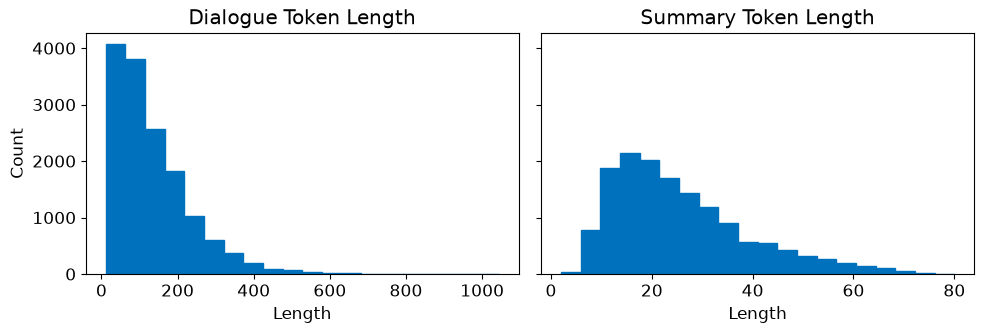

In [36]:
# queremos saber la distribución de los tokens de los inputs y outputs
d_len = [len(tokenizer.encode(s)) for s in dataset_samsum["train"]["dialogue"]] # lista de tokens por diálogo
s_len = [len(tokenizer.encode(s)) for s in dataset_samsum["train"]["summary"]] # lista de tokens por resúmen
# Ojo! [len(tokenizer.encode(s)) = len(tokenizer(s)["input_ids"]) -> Así obteneomos los inputs_ID

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
# fig -> La figura completa, el lienzo
# axes -> un array cons 2 ejes: -> porque hemos pedido 1,2 -> 1 fila 2 columnas
    # axes[0]= gráfico izquierdo
    # axes[1]-> gráfico derecho
# figsize(10,3.5) tamaño de la figura
# sharey=True ambas figuras (histogramas comparten eje "Y"


axes[0].hist(d_len, bins=20, color="C0", edgecolor="C0") # histograma con las longitudes de los diálogos
# estructura de his():
    #axes[0].hist(
       # d_len,          # datos
       # bins=20,        # número de intervalos
       # color="C0",     # color de las barras. c0= azul
       # edgecolor="C0"  # color del borde

axes[0].set_title("Dialogue Token Length")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Count")
axes[1].hist(s_len, bins=20, color="C0", edgecolor="C0")
axes[1].set_title("Summary Token Length")
axes[1].set_xlabel("Length")
plt.tight_layout() # ajusta automáticamente los espacios entre gráficos para evitar solapamientos.
plt.show() # muestra la figura

```text
PEGASUS es un modelo encoder- decoder
DIÁLOGO
   ↓
ENCODER
   ↓
representación del diálogo
   ↓
DECODER
   ↓
RESUMEN



Un batch tendrña estas claves:
- example_batch["dialogue"] → lista de diálogos
- example_batch["summary"] → lista de resúmenes

example_batch["dialogue"] son los textos que entrarán en el encoder

El tokenizer devuelve algo conceptualmente así:

```python
input_encodings = {
    "input_ids": [
        [123, 456, 789, 1],
        [872, 92, 445, 821, 1],
        ...
    ],
    "attention_mask": [
        [1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        ...
    ]
}
```

Así que:

```text
input_encodings
├── input_ids
└── attention_mask
```

`max_length=1024` establece el límite máximo.

## Llegamos a la parte importante

```python
with tokenizer.as_target_tokenizer():
    target_encodings = tokenizer(
        example_batch["summary"],
        max_length=128,
        truncation=True
    )
```

La clave está en que no estamos tokenizando el mismo tipo de secuencia.

Antes tokenizábamos:

```text
dialogue
   ↓
INPUT DEL ENCODER
```

Ahora tokenizamos:

```text
summary
   ↓
TARGET DEL DECODER
```

En modelos `seq2seq`, históricamente algunos tokenizers podían tener un comportamiento distinto para las entradas y para los targets.

Conceptualmente:

```text
modo input

tokenizer(dialogue)
      ↓
tokens preparados para el ENCODER
```

frente a:

```text
modo target

tokenizer(summary)
      ↓
tokens preparados como objetivo del DECODER
```

`as_target_tokenizer()` es un *context manager* que cambia temporalmente el tokenizer a modo target:

```python
with tokenizer.as_target_tokenizer():
```

Conceptualmente:

```text
tokenizer está en INPUT MODE
          ↓
entra en with
          ↓
tokenizer pasa a TARGET MODE
          ↓
tokeniza summaries
          ↓
sale del with
          ↓
tokenizer vuelve a INPUT MODE
```

Por eso usan `with`.

Es el mismo patrón de Python que:

```python
with open("archivo.txt") as f:
    ...
```

El contexto tiene un inicio y un final controlado.

Aquí sería conceptualmente:

```python
with tokenizer.as_target_tokenizer():
    # dentro: modo target
```

Al salir:

```text
modo input restaurado
```

### ¿Pero qué cambia exactamente?

Depende del tokenizer y del modelo.

Puede afectar a aspectos como:

- tokens especiales;
- prefijos;
- configuración específica del tokenizer;
- tratamiento de la secuencia objetivo.

La API antigua de Transformers quería que dijeras explícitamente:

> Ojo: esto que voy a tokenizar ahora no es una entrada. Es el target.

Por eso:

```python
with tokenizer.as_target_tokenizer():
```

En las versiones modernas esto se expresa normalmente mediante:

```python
tokenizer(text_target=...)
```

Pero para entender Tunstall, piensa:

```text
as_target_tokenizer()
=
"tokeniza lo siguiente como secuencia objetivo"
```

Eso es lo esencial.

## 4. Tokenizamos los resúmenes

Dentro del contexto:

```python
target_encodings = tokenizer(
    example_batch["summary"],
    max_length=128,
    truncation=True
)
```

Ahora tenemos algo parecido a:

```python
target_encodings = {
    "input_ids": [
        [765, 231, 98, 1],
        [231, 821, 92, 54, 1],
        ...
    ],
    "attention_mask": [
        ...
    ]
}
```

Pero aquí hay algo que suele confundir:

```python
target_encodings["input_ids"]
```

se llaman `input_ids`.

¿Por qué, si son targets?

Porque desde el punto de vista del tokenizer siguen siendo IDs de tokens.

El tokenizer no sabe que luego los vas a utilizar como `labels`.

Para él:

```text
texto
 ↓
tokenizer
 ↓
input_ids
```

Siempre.

Es nuestro código el que posteriormente dice:

```python
"labels": target_encodings["input_ids"]
```

Ahí es donde les damos el papel de targets.

## 5. El `return`

```python
return {
    "input_ids": input_encodings["input_ids"],
    "attention_mask": input_encodings["attention_mask"],
    "labels": target_encodings["input_ids"]
}
```

Esta es probablemente la línea conceptualmente más importante de toda la función.

Estamos construyendo la estructura que espera el modelo para entrenamiento:

```text
input_ids
→ tokens del DIÁLOGO

attention_mask
→ qué tokens del DIÁLOGO debe atender el encoder

labels
→ tokens del RESUMEN CORRECTO
```

Por ejemplo:

```python
{
    "input_ids": [101, 452, 782, 1],
    "attention_mask": [1, 1, 1, 1],
    "labels": [871, 923, 72, 1]
}
```

Conceptualmente:

```text
input_ids
"Amanda: I baked cookies..."
          ↓
       PEGASUS
          ↓
predicción del decoder
          ↕
labels
"Amanda baked cookies..."
          ↓
         LOSS
```

Durante el entrenamiento, el modelo compara sus predicciones con:

```python
labels
```

y calcula la pérdida.

Esta es la transformación fundamental:

```text
dialogue → input_ids
summary  → labels
```

Eso es lo que hace realmente `convert_examples_to_features()`.

## 6. Aplicamos la función al dataset

```python
dataset_samsum_pt = dataset_samsum.map(
    convert_examples_to_features,
    batched=True
)
```

Aquí entra `map()` de Hugging Face Datasets.

Conceptualmente:

```text
dataset_samsum

ejemplos originales:
id
dialogue
summary

      ↓ convert_examples_to_features()

añadir:
input_ids
attention_mask
labels
```

`map()` aplica la función al dataset.

Como:

```python
batched=True
```

no llama a la función ejemplo por ejemplo:

```text
ejemplo 1 → función
ejemplo 2 → función
ejemplo 3 → función
```

sino por grupos:

```text
batch de ejemplos → función
batch de ejemplos → función
batch de ejemplos → función
```

Esto permite que el tokenizer procese listas de textos y suele ser mucho más eficiente.

El resultado se guarda en:

```python
dataset_samsum_pt
```

Y, muy importante, no modifica `dataset_samsum` en el sitio.

Tienes:

```text
dataset_samsum
→ dataset original

dataset_samsum_pt
→ dataset transformado
```

## 7. Seleccionamos las columnas relevantes

```python
columns = ["input_ids", "labels", "attention_mask"]
```

Aquí simplemente crean una lista:

```python
[
    "input_ids",
    "labels",
    "attention_mask"
]
```

¿Por qué esas tres?

Porque son las que necesita el modelo durante el entrenamiento:

```text
input_ids       → entrada
attention_mask  → máscara de atención
labels          → objetivo
```

Ya no nos interesa directamente:

```text
id
dialogue
summary
```

para alimentar PEGASUS.

## 8. `set_format(type="torch")`

```python
dataset_samsum_pt.set_format(
    type="torch",
    columns=columns
)
```

Esto le dice al dataset:

> Cuando acceda a estas columnas, devuélvemelas en formato PyTorch.

Antes podrías tener:

```python
dataset_samsum_pt["train"][0]["input_ids"]
```

como una lista de Python:

```python
[121, 523, 872, 1]
```

Después de:

```python
set_format(type="torch", ...)
```

se devolverá como:

```python
tensor([121, 523, 872, 1])
```

Es decir:

```text
listas Python
     ↓
set_format(type="torch")
     ↓
tensores PyTorch
```

Matiz importante: `set_format()` no está entrenando ni moviendo todo el dataset a la GPU.

No hace:

```text
dataset completo → VRAM
```

Simplemente configura cómo se presentan las columnas al acceder a ellas.

## El flujo completo de esta celda

```text
SAMSum original
│
├── dialogue
└── summary
       ↓
convert_examples_to_features()
       ↓
dialogue
→ tokenizer INPUT mode
→ input_ids + attention_mask

summary
→ tokenizer TARGET mode
→ token IDs
→ labels
       ↓
dataset.map(..., batched=True)
       ↓
dataset tokenizado
       ↓
set_format(type="torch")
       ↓
datos preparados para PyTorch / PEGASUS
```

La idea clave es:

```text
dialogue → input_ids
summary  → labels
```

`as_target_tokenizer()` simplemente le indica al tokenizer antiguo de Transformers que ahora está procesando la secuencia objetivo del modelo `seq2seq`, no la entrada del encoder.

In [37]:
#hide_output
# El objetivo de todo ese código es transformar un dataset de texto en un dataset 
# que PEGASUS pueda utilizar para entrenarse. Es decir:
# Convertir pares (diálogo, resumen) en tensores (input_ids, attention_mask, labels) listos para entrenar un modelo seq2seq.
# 1. Tokeniza los diálogos obteniendo<.
    # input_ids
    # attention_mask
# 2. Tokeniza los resúmenes, obteniendo los IDs de los tokens que luego se usarán como
    # labels
# 3. Aplica esta transformación a todo el dataset mediante map()
# 4. Configura el el datataset para que devuelva tensores de PyTorch, listos para alimentar el modelo

# al final pasaremos de  dialogos y resumenes a inputs_ids, attention_mask y labels
def convert_examples_to_features(example_batch):
    
    # preparamos las entradas del encoder (PEGASUS  es un modelo encoder - decoder)
    
    input_encodings = tokenizer(example_batch["dialogue"], max_length=1024,
                                truncation=True) #cada diálogo no podrá exceder de 1024 tokens
    
    with tokenizer.as_target_tokenizer(): # tokens preparados como objetivos del Decoder
        target_encodings = tokenizer(example_batch["summary"], max_length=128,
                                     truncation=True) # cada resumen no podrá exceder de 128 tokens
    
    return {"input_ids": input_encodings["input_ids"], # tokens del diálogo
            "attention_mask": input_encodings["attention_mask"], #qué tokens del dialogo debe atender el encoder
            "labels": target_encodings["input_ids"]} # tokens del resumen correcto

dataset_samsum_pt = dataset_samsum.map(convert_examples_to_features, 
                                       batched=True) # Aplicamos la función al dataset, guardandolo en otra variable
columns = ["input_ids", "labels", "attention_mask"] # seleccionamos las columnas relevantes
dataset_samsum_pt.set_format(type="torch", columns=columns) # cuando accedeas a estas columnas devuélvemelas en formato pt -> tensor

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

/home/srmjf/transf/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

In [ ]:
# en la API moderna ya no se usa as_target_tokenizer(). Se haría así
# Se utiliza text_target=...
def convert_examples_to_features(example_batch):
    model_inputs = tokenizer(
        example_batch["dialogue"],
        max_length=1024,
        truncation=True
    )

    # tokenizamos los resúmenes (objetivos del decoder)
    labels = tokenizer(
        text_target=example_batch["summary"],
        max_length=128,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"] # copiamos labels["input_ids"] dentro del diccionario model_inputs bajo la clave "labels"

    return model_inputs # Devuelve un diccionario con input_ids, attention_mask y labels

# Aplicamos la transformación a todo el dataset
dataset_samsum_pt = dataset_samsum.map(
    convert_examples_to_features,
    batched=True,
    remove_columns=dataset_samsum["train"].column_names) # Aplicamos la función al dataset, guardandolo en otra variable
columns = ["input_ids", "labels", "attention_mask"] # seleccionamos las columnas relevantes que usará el modelo
dataset_samsum_pt.set_format(type="torch", columns=columns) # cuando accedeas a estas columnas devuélvemelas en formato pt -> tensor

In [38]:
#hide_input

#id teacher-forcing
#alt Decoder input and label alignemt for text generation.
#caption Decoder input and label alignemt for text generation.
text = ['PAD','Transformers', 'are', 'awesome', 'for', 'text', 'summarization']
rows = []
for i in range(len(text)-1):
    rows.append({'step': i+1, 'decoder_input': text[:i+1], 'label': text[i+1]})
pd.DataFrame(rows).set_index('step')

,decoder_input,label
step,,
1,[PAD],Transformers
2,"[PAD, Transformers]",are
3,"[PAD, Transformers, are]",awesome
4,"[PAD, Transformers, are, awesome]",for
5,"[PAD, Transformers, are, awesome, for]",text
6,"[PAD, Transformers, are, awesome, for, text]",summarization


In [39]:
from transformers import DataCollatorForSeq2Seq
# DataCollatorForSeq2Seq -> varias funciones:
# 1. Padding dinámico enj IDs y Labels
# 2. Convierte PAD en -inf
# 3. Desplazamiento de 1 a la derecha -> decoder_input_ids (para esto encesita saber el modelo)

seq2seq_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [41]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='pegasus-samsum', num_train_epochs=1, warmup_steps=500,
    per_device_train_batch_size=1, per_device_eval_batch_size=1,
    weight_decay=0.01, logging_steps=10, push_to_hub=True,
    eval_strategy='steps', eval_steps=500, save_steps=1e6,
    gradient_accumulation_steps=16)

In [42]:
#hide_output
from huggingface_hub import notebook_login

notebook_login()

In [45]:
# Para reducir tiempos de entrenamiento
train_small = dataset_samsum_pt["train"].shuffle(seed=42).select(range(1000))
valid_small = dataset_samsum_pt["validation"].shuffle(seed=42).select(range(100))
test_small = dataset_samsum["test"].shuffle(seed=42).select(range(100))

In [46]:
# hide_output
trainer = Trainer(model=model, args=training_args,
                  tokenizer=tokenizer, data_collator=seq2seq_data_collator,
                  train_dataset=train_small, 
                  eval_dataset=valid_small)

/tmp/ipykernel_462/298629224.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=training_args,


In [47]:
# hide_output
trainer.train()
score = evaluate_summaries_pegasus(
    test_small, rouge_metric, trainer.model, tokenizer,
    batch_size=8, column_text="dialogue", column_summary="summary")

rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=[f"pegasus"])

{'loss': 3.1324, 'grad_norm': 100.77637481689453, 'learning_rate': 9e-07, 'epoch': 0.16}
{'loss': 3.0816, 'grad_norm': 11.374287605285645, 'learning_rate': 1.9e-06, 'epoch': 0.32}
{'loss': 3.0462, 'grad_norm': 61.9191780090332, 'learning_rate': 2.9e-06, 'epoch': 0.48}
{'loss': 3.0206, 'grad_norm': 8.486113548278809, 'learning_rate': 3.9e-06, 'epoch': 0.64}
{'loss': 2.9606, 'grad_norm': 43.430511474609375, 'learning_rate': 4.9000000000000005e-06, 'epoch': 0.8}
{'loss': 3.0956, 'grad_norm': 18.582626342773438, 'learning_rate': 5.9e-06, 'epoch': 0.96}


/home/srmjf/transf/lib/python3.12/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 128, 'min_length': 32, 'num_beams': 8, 'length_penalty': 0.8}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


{'train_runtime': 2159.7779, 'train_samples_per_second': 0.463, 'train_steps_per_second': 0.029, 'train_loss': 3.0230797131856284, 'epoch': 1.0}


100%|██████████████████████████████████████████████████████████████████████████████| 13/13 [16:05<00:00, 74.24s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.311375,0.10677,0.244723,0.244207


In [48]:
# hide_input
pd.DataFrame(rouge_dict, index=[f"pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.311375,0.10677,0.244723,0.244207


In [53]:
import os

print(os.getcwd())

/mnt/d/Repos Github/nlp-with-transformers


In [57]:
save_dir = "/home/srmjf/pegasus-samsum-final"

trainer.args.push_to_hub = False

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Modelo guardado en: {save_dir}")

Modelo guardado en: /home/srmjf/pegasus-samsum-final


In [59]:
import os

os.path.exists("/home/srmjf/pegasus-samsum-final")

True

In [60]:
os.listdir("/home/srmjf/pegasus-samsum-final")

['tokenizer.json',
 'config.json',
 'special_tokens_map.json',
 'spiece.model',
 'tokenizer_config.json',
 'training_args.bin',
 'model.safetensors',
 'generation_config.json']

In [62]:
import os
print(os.environ.get("HF_HUB_DISABLE_XET"))

1


In [4]:
# lo subo de otra manera

from huggingface_hub import HfApi

api = HfApi()

repo_id = "srmjfba/pegasus-samsum"

api.create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True
)

api.upload_folder(
    repo_id=repo_id,
    repo_type="model",
    folder_path="/home/srmjf/pegasus-samsum-final",
    commit_message="Training complete!"
)

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.78k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/srmjfba/pegasus-samsum/commit/974ae10c61e89d8dd09ed9da776861c4e52f2a91', commit_message='Training complete!', commit_description='', oid='974ae10c61e89d8dd09ed9da776861c4e52f2a91', pr_url=None, repo_url=RepoUrl('https://huggingface.co/srmjfba/pegasus-samsum', endpoint='https://huggingface.co', repo_type='model', repo_id='srmjfba/pegasus-samsum'), pr_revision=None, pr_num=None)

In [63]:
# hide_output
trainer.push_to_hub("Training complete!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

OSError: I/O error: I/O error: No such file or directory (os error 2)

### Generating Dialogue Summaries

In [22]:
# hide
import transformers # mportamos el módulo completo:(Trainer, AutoTokenizer, AutoModel, pipeline, logging...
transformers.logging.set_verbosity_error() # muestra sólo errores. loggig tiene 3 niveles
    # DEBUG
    # INFO
    # WARNING
    # ERROR

In [23]:
gen_kwargs = {"length_penalty": 0.8, "num_beams":8, "max_length": 128} # argumnetos que se pasarán a pipe()
sample_text = dataset_samsum["test"][0]["dialogue"]
reference = dataset_samsum["test"][0]["summary"]
pipe = pipeline("summarization", model="transformersbook/pegasus-samsum")

print("Dialogue:")
print(sample_text)
print("\nReference Summary:")
print(reference)
print("\nModel Summary:")
print(pipe(sample_text, **gen_kwargs)[0]["summary_text"])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Reference Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact
Larry.

Model Summary:
Amanda can't find Betty's number. Larry called Betty last time they were at the
park together. Hannah wants Amanda to text Larry instead of calling Betty.


In [24]:
custom_dialogue = """\
Thom: Hi guys, have you heard of transformers?
Lewis: Yes, I used them recently!
Leandro: Indeed, there is a great library by Hugging Face.
Thom: I know, I helped build it ;)
Lewis: Cool, maybe we should write a book about it. What do you think?
Leandro: Great idea, how hard can it be?!
Thom: I am in!
Lewis: Awesome, let's do it together!
"""
print(pipe(custom_dialogue, **gen_kwargs)[0]["summary_text"])

Thom, Lewis and Leandro are going to write a book about transformers. Thom
helped build a library by Hugging Face. They are going to do it together.


## Conclusion